In [1]:
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

# Teorema del limite centrale

Il teorema del limite centrale afferma:
Se si prendono molti campioni casuali di dimensione sufficientemente grande da una popolazione con qualsiasi distribuzione (con media 
𝜇 e deviazione standard 𝜎), la distribuzione delle medie campionarie tende ad essere normale (gaussiana), con media 𝜇 e deviazione standard $\frac{𝜎}{𝑛}$, dove 𝑛 è la dimensione del campione.

## Esempio con caso lancio di un dado

Si prende in considerazione il lancio di un dado a 6 facce regolare, quindi dove ogni faccia ha la stessa probabilità di essere estratta.

La distribuzione di probabilità è quindi quella uniforme, con valore costante = $\frac{1}{6}$

$f(X) = \frac{1}{6}$ con  $X \in \left\{1,2,3,4,5,6\right\}$

La media della popolazione è $\mu = \frac{1+2+3+4+5+6}{6} = 3.5$

Media popolazione: 3.5
Deviazione standard della popolazione: 1.707825127659933


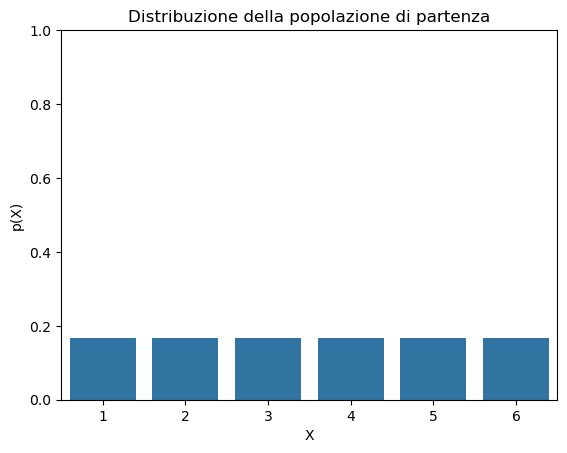

In [43]:
X = np.arange(1,7)

print(f"Media popolazione: {X.mean()}")
print(f"Deviazione standard della popolazione: {X.std()}")

plt.figure()
sns.barplot(x=X,y=1/6)
plt.ylim([0,1])
plt.title("Distribuzione della popolazione di partenza")
plt.xlabel("X")
plt.ylabel("p(X)")
plt.show()

La distribuzione di partenza non è normale, quindi è un buon modo per testare questo teorema. 

## Come testare il teorema del limite centrale in questo caso

Si prendono in esame N esperimenti (con N molto grande, es 1000), ognuno composto da n lanci indipendenti del dado (es n = 50).

In questo contesto le analogie con l'enunciato sono:
- esperimento -> campione
- numero di lanci (n) -> numerosità del campione
- risultato del lancio -> elemento del campione (unità statistica)


In [11]:
n_lanci = 50 #numerosità campionaria
n_esperimenti = 1000 #numero di campioni estratti dalla popolazione (ogni campione ha n_lanci elementi)

lanci = np.random.randint(1,7,(n_esperimenti, n_lanci)) #ogni riga è un campione

#check
print(lanci.shape)

#calcolo medie campionarie
medie = lanci.mean(axis=1)

#check
print(medie.shape)

(1000, 50)
(1000,)


Il vettore `medie` ora contiene le medie campionarie per gli N campioni (esperimenti) estratti. 

È questo vettore che segue una distribuzione normale, con media pari a quella della **popolazione** di partenza (quindi pari al vero valore)

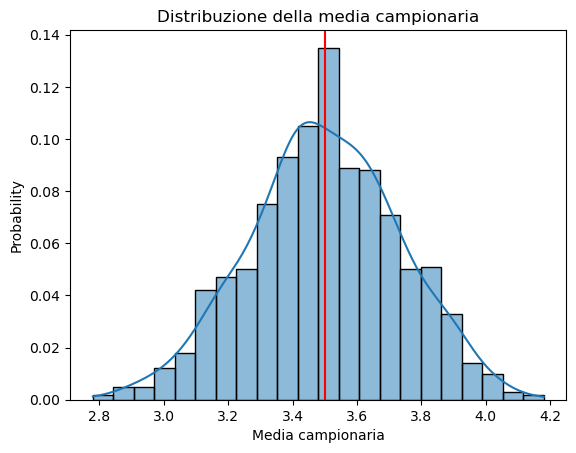

In [18]:
plt.figure()
sns.histplot(x=medie,stat="probability",kde=True)
plt.title("Distribuzione della media campionaria")
plt.xlabel("Media campionaria")
plt.axvline(3.5,color="r")
plt.show()

Come si vede dalla kde stimata, distribuzione della media campionaria è una gaussiana, centrata nel valore medio reale di 3.5, sebbene la distribuzione della popolazione di partenza, non è una normale.

## Add on
Si può mettere il codice delle due celle sovrastanti in una funzione, in modo da poter sperimentare cosa succede con diversi valori di N e n.

In [44]:
def teorema_limite_centrale(n_esperimenti=1000, n_lanci=50):
    """
    Testa il teorema del limite centrale, immaginando di avere n_esperimenti campioni, composti da n_lanci elementi

    Input:
    n_esperimenti (int):
        numero di esperimenti eseguiti, i.e. numero di campioni estratti dalla popolazione
    n_lanci (int):
        numero di lanci di ogni esperimento, i.e. numerosità campionaria 
    """
    lanci = np.random.randint(1,7,(n_esperimenti, n_lanci)) #ogni riga è un campione
    
    #calcolo medie campionarie
    medie = lanci.mean(axis=1)

    plt.figure()
    sns.histplot(x=medie,stat="probability",kde=True)
    plt.title(f"Distribuzione della media campionaria con n={n_lanci}")
    plt.xlabel("Media campionaria")
    plt.axvline(3.5,color="r")
    plt.xlim([2,5])
    plt.show()


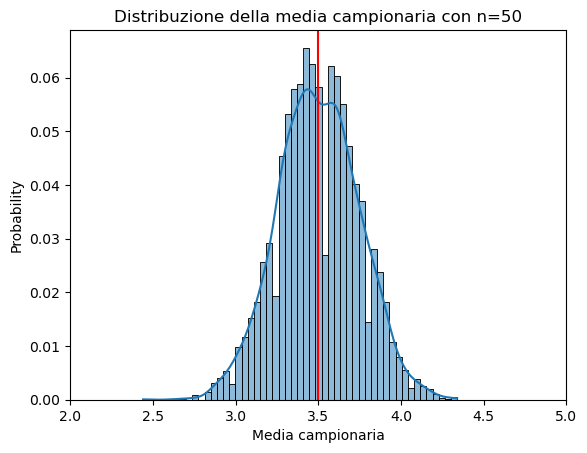

In [50]:
teorema_limite_centrale(5000,50)

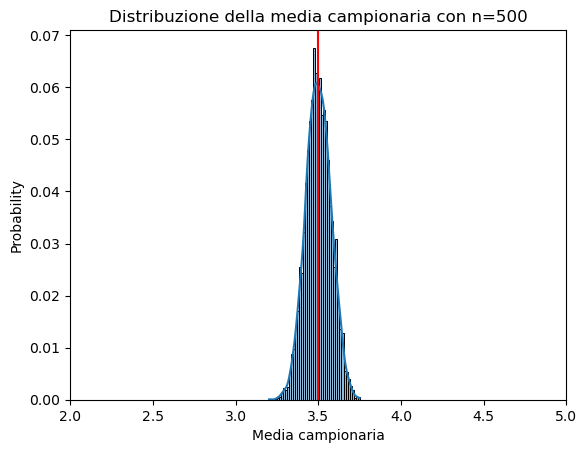

In [51]:
teorema_limite_centrale(5000,500)

Come si vede dalle due prove qui sopra, aumentando n, si ottiene una campana più stretta, poichè la varianza della gaussiana va come $\frac{\sigma^2}{n}$ dove $\sigma^2$ è la varianza della popolazione di partenza (quindi una costante qui)